# TODOs
- Need to implement TensorRT for model acceleration

2026-05-12 21:55:17.601378471 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card1": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"
2026-05-12 21:55:17.602526016 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


Device target: raspi
Using model: /home/jl/realsense/models/yolo11n.tflite
Loaded onnx detector from: /home/jl/realsense/models/yolo11n.onnx
Loaded cached RGB-D from: /home/jl/realsense/captures_3d
Point cloud Z range after filtering: min=536.0mm, max=996.0mm, p99=992.0mm

Detected objects with 3D and segmentation summary:
1. bottle score=0.85, bbox=(237, 240, 297, 387), center_mm=(-50.4, 78.0, 571.5), size_mm=(44.9, 128.2, 89.0), seg_px=6882
2. keyboard score=0.79, bbox=(445, 186, 580, 422), center_mm=(205.8, 103.3, 645.8), size_mm=(136.3, 135.6, 125.7), seg_px=20512
3. bottle score=0.67, bbox=(422, 1, 464, 80), center_mm=(203.6, -327.7, 1011.3), size_mm=(49.3, 73.9, 124.7), seg_px=2075
4. cup score=0.48, bbox=(244, 66, 291, 127), center_mm=(-87.2, -229.6, 1008.2), size_mm=(70.0, 74.1, 62.4), seg_px=2451
5. remote score=0.42, bbox=(395, 149, 429, 256), center_mm=(116.0, -44.0, 745.2), size_mm=(37.5, 118.2, 66.5), seg_px=3012


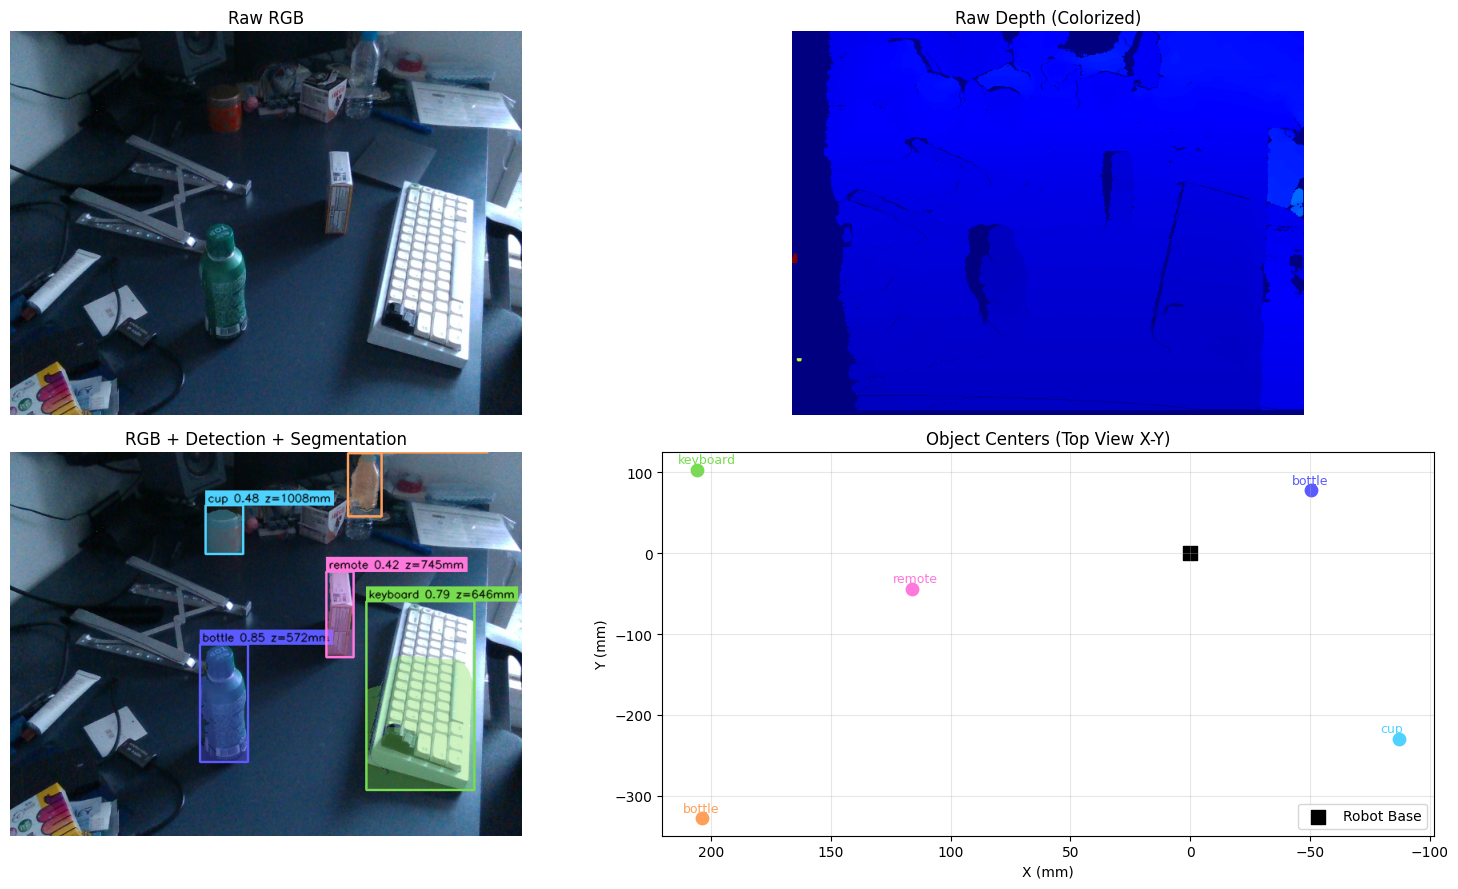

In [1]:
import json
from pathlib import Path
from types import SimpleNamespace

import cv2
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
try:
    import pyrealsense2 as rs
    RS_IMPORT_ERROR = None
except Exception as e:
    rs = None
    RS_IMPORT_ERROR = e

# Set this to either 'raspi' or 'jetson_orin_nx'.
DEVICE_TARGET = "raspi"

if DEVICE_TARGET not in {"raspi", "jetson_orin_nx"}:
    raise ValueError("DEVICE_TARGET must be 'raspi' or 'jetson_orin_nx'")

# ============================================================================
# Robot base (platform origin) position in CAMERA-CENTERED coordinate system
# Default: (0, 0, 0) = at camera center
# Adjust these values if your robot base is offset from the camera
# Example offsets:
#   - Left 50mm, Down 100mm, Behind 50mm: [-50.0, -100.0, 50.0]
#   - At camera center: [0.0, 0.0, 0.0]  <-- Current default
# ============================================================================
ROBOT_BASE_MM = np.array([0.0, 0.0, 500.0], dtype=np.float32)

BASE_DIR = Path.cwd()
CACHE_DIR = BASE_DIR / "captures_3d"
CACHE_RGB_PATH = CACHE_DIR / "cached_rgb.png"
CACHE_DEPTH_PATH = CACHE_DIR / "cached_depth.npy"
CACHE_INTRINSICS_PATH = CACHE_DIR / "cached_intrinsics.json"
USE_SAVED_RGBD_IF_AVAILABLE = True
SAVE_CAPTURED_RGBD = True

MODEL_PATHS = {
    "raspi": BASE_DIR / "models" / "yolo11n.tflite",
    "jetson_orin_nx": BASE_DIR / "models" / "yolo11n.onnx",
}
MODEL_PATH = MODEL_PATHS[DEVICE_TARGET]

try:
    from tflite_runtime.interpreter import Interpreter
except Exception:
    Interpreter = None

try:
    import onnxruntime as ort
except Exception:
    ort = None

try:
    import plotly.graph_objects as go
except Exception:
    go = None

COCO80_NAMES = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light',
    'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee',
    'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

VIS_PALETTE_BGR = [
    (255, 90, 90),
    (80, 220, 120),
    (90, 160, 255),
    (255, 210, 80),
    (220, 120, 255),
]

class BaseYoloDetector:
    def __init__(self, model_path: Path, input_size: int = 640, conf_th: float = 0.25, nms_th: float = 0.45):
        if not model_path.exists():
            raise FileNotFoundError(f"Model not found: {model_path}")
        self.model_path = model_path
        self.input_size = input_size
        self.conf_th = conf_th
        self.nms_th = nms_th

    def _letterbox(self, image: np.ndarray) -> tuple[np.ndarray, float, int, int]:
        h, w = image.shape[:2]
        scale = min(self.input_size / w, self.input_size / h)
        nw = int(round(w * scale))
        nh = int(round(h * scale))
        px = (self.input_size - nw) // 2
        py = (self.input_size - nh) // 2
        resized = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
        canvas = np.full((self.input_size, self.input_size, 3), 114, dtype=np.uint8)
        canvas[py:py + nh, px:px + nw] = resized
        return canvas, scale, px, py

    def _prepare_input(self, image: np.ndarray) -> tuple[np.ndarray, float, int, int]:
        letterboxed, scale, px, py = self._letterbox(image)
        rgb = cv2.cvtColor(letterboxed, cv2.COLOR_BGR2RGB)
        input_tensor = rgb.transpose(2, 0, 1)[None].astype(np.float32) / 255.0
        return input_tensor, scale, px, py

    def _normalize_predictions(self, predictions: np.ndarray) -> np.ndarray:
        arr = np.array(predictions)
        if arr.ndim == 3:
            arr = arr[0]
        if arr.ndim == 2 and arr.shape[0] < arr.shape[1]:
            arr = arr.T
        return arr

    def _postprocess(self, image: np.ndarray, preds: np.ndarray, scale: float, px: int, py: int) -> list[dict]:
        h, w = image.shape[:2]
        boxes, scores, class_ids = [], [], []

        for row in preds:
            if row.shape[0] < 6:
                continue

            cx, cy, bw, bh = row[:4]
            objectness = float(row[4])
            class_scores = row[5:]
            if class_scores.size == 0:
                continue

            class_id = int(np.argmax(class_scores))
            class_conf = float(class_scores[class_id])
            score = objectness * class_conf
            if score < self.conf_th:
                continue

            x1 = int((cx - bw / 2 - px) / scale)
            y1 = int((cy - bh / 2 - py) / scale)
            x2 = int((cx + bw / 2 - px) / scale)
            y2 = int((cy + bh / 2 - py) / scale)

            x1 = max(0, min(w - 1, x1))
            y1 = max(0, min(h - 1, y1))
            x2 = max(0, min(w - 1, x2))
            y2 = max(0, min(h - 1, y2))
            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2 - x1, y2 - y1])
            scores.append(score)
            class_ids.append(class_id)

        if not boxes:
            return []

        kept = cv2.dnn.NMSBoxes(boxes, scores, self.conf_th, self.nms_th)
        if len(kept) == 0:
            return []

        detections = []
        for idx in np.array(kept).reshape(-1):
            x, y, bw, bh = boxes[int(idx)]
            class_id = class_ids[int(idx)]
            detections.append({
                "bbox": (x, y, x + bw, y + bh),
                "score": float(scores[int(idx)]),
                "class_id": class_id,
                "class_name": COCO80_NAMES[class_id] if class_id < len(COCO80_NAMES) else str(class_id),
            })
        return detections

    def infer(self, input_tensor: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def detect(self, image: np.ndarray) -> list[dict]:
        input_tensor, scale, px, py = self._prepare_input(image)
        raw = self.infer(input_tensor)
        preds = self._normalize_predictions(raw)
        return self._postprocess(image, preds, scale, px, py)


class TFLiteYoloDetector(BaseYoloDetector):
    def __init__(self, model_path: Path, input_size: int = 640, conf_th: float = 0.25, nms_th: float = 0.45):
        super().__init__(model_path, input_size, conf_th, nms_th)
        if Interpreter is None:
            raise RuntimeError("tflite_runtime is not installed in this environment.")
        try:
            self.interpreter = Interpreter(model_path=str(model_path))
        except Exception as e:
            size_bytes = model_path.stat().st_size if model_path.exists() else -1
            raise RuntimeError(
                f"Failed to load TFLite model: {model_path} (size={size_bytes} bytes). {e}"
            ) from e
        self.interpreter.allocate_tensors()
        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

    def infer(self, input_tensor: np.ndarray) -> np.ndarray:
        self.interpreter.set_tensor(self.input_details[0]["index"], input_tensor)
        self.interpreter.invoke()
        return self.interpreter.get_tensor(self.output_details[0]["index"])


class ONNXYoloDetector(BaseYoloDetector):
    def __init__(self, model_path: Path, input_size: int = 640, conf_th: float = 0.25, nms_th: float = 0.45):
        super().__init__(model_path, input_size, conf_th, nms_th)
        if ort is None:
            raise RuntimeError("onnxruntime is not installed in this environment.")
        self.session = ort.InferenceSession(str(model_path), providers=["CPUExecutionProvider"])
        self.input_name = self.session.get_inputs()[0].name

    def infer(self, input_tensor: np.ndarray) -> np.ndarray:
        outputs = self.session.run(None, {self.input_name: input_tensor})[0]
        arr = np.array(outputs)
        if arr.ndim == 3:
            arr = arr[0]
        if arr.ndim == 2 and arr.shape[0] < arr.shape[1]:
            arr = arr.T

        if arr.shape[1] == 84:
            objectness = np.ones((arr.shape[0], 1), dtype=arr.dtype)
            arr = np.concatenate([arr[:, :4], objectness, arr[:, 4:]], axis=1)
        return arr


def build_detector(device_target: str, model_path: Path) -> BaseYoloDetector:
    # Prefer model based on DEVICE_TARGET, then fallback to the other model if load fails.
    if device_target == "raspi":
        primary = ("tflite", model_path)
        fallback = ("onnx", MODEL_PATHS["jetson_orin_nx"])
    else:
        primary = ("onnx", model_path)
        fallback = ("tflite", MODEL_PATHS["raspi"])

    errors = []
    for fmt, path in (primary, fallback):
        if not path.exists():
            errors.append(f"{fmt} missing: {path}")
            continue
        try:
            if fmt == "tflite":
                detector = TFLiteYoloDetector(path)
            else:
                detector = ONNXYoloDetector(path)
            print(f"Loaded {fmt} detector from: {path}")
            return detector
        except Exception as e:
            errors.append(f"{fmt} load failed ({path}): {e}")

    raise RuntimeError("Could not initialize detector. Details: " + " | ".join(errors))


def estimate_3d_box(depth_image: np.ndarray, intrinsics, bbox: tuple[int, int, int, int]) -> dict | None:
    h, w = depth_image.shape[:2]
    x1, y1, x2, y2 = bbox
    x1 = max(0, min(w - 1, int(x1)))
    y1 = max(0, min(h - 1, int(y1)))
    x2 = max(0, min(w, int(x2)))
    y2 = max(0, min(h, int(y2)))
    if x2 - x1 < 6 or y2 - y1 < 6:
        return None

    roi = depth_image[y1:y2, x1:x2]
    valid = roi[roi > 0]
    if valid.size < 20:
        return None

    anchor_depth = int(np.percentile(valid, 40))
    band_mm = max(80, int(anchor_depth * 0.12))
    points_mm = []

    step = max(2, min((x2 - x1) // 24 + 1, (y2 - y1) // 24 + 1))
    for py in range(y1, y2, step):
        for px in range(x1, x2, step):
            depth_mm = int(depth_image[py, px])
            if depth_mm <= 0 or abs(depth_mm - anchor_depth) > band_mm:
                continue
            z_m = depth_mm / 1000.0
            x_m = (float(px) - intrinsics.ppx) / intrinsics.fx * z_m
            y_m = (float(py) - intrinsics.ppy) / intrinsics.fy * z_m
            points_mm.append([x_m * 1000.0, y_m * 1000.0, z_m * 1000.0])

    if len(points_mm) < 12:
        return None

    points_mm = np.asarray(points_mm, dtype=np.float32)
    min_xyz = np.percentile(points_mm, 5, axis=0)
    max_xyz = np.percentile(points_mm, 95, axis=0)
    center_xyz = (min_xyz + max_xyz) / 2.0
    size_xyz = max_xyz - min_xyz
    return {
        "min_xyz_mm": min_xyz,
        "max_xyz_mm": max_xyz,
        "center_xyz_mm": center_xyz,
        "size_xyz_mm": size_xyz,
        "anchor_depth_mm": anchor_depth,
        "band_mm": band_mm,
    }


def depth_segmentation_mask(depth_image: np.ndarray, bbox: tuple[int, int, int, int], anchor_depth_mm: int, band_mm: int) -> np.ndarray:
    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(depth_image.shape[1], x2)
    y2 = min(depth_image.shape[0], y2)

    mask = np.zeros(depth_image.shape[:2], dtype=bool)
    roi = depth_image[y1:y2, x1:x2]
    local_mask = (roi > 0) & (np.abs(roi.astype(np.int32) - int(anchor_depth_mm)) <= int(band_mm))
    mask[y1:y2, x1:x2] = local_mask
    return mask


def sample_raw_point_cloud(
    depth_image: np.ndarray,
    color_image: np.ndarray,
    intrinsics,
    step: int = 4,
    max_points: int = 14000,
    min_depth_mm: float = 120.0,
    max_depth_mm: float = 3000.0,
    trim_low_pct: float = 1.0,
    trim_high_pct: float = 99.0,
):
    ys = np.arange(0, depth_image.shape[0], step)
    xs = np.arange(0, depth_image.shape[1], step)
    grid_x, grid_y = np.meshgrid(xs, ys)

    d_mm = depth_image[grid_y, grid_x].astype(np.float32)
    valid = (d_mm >= min_depth_mm) & (d_mm <= max_depth_mm)
    if not np.any(valid):
        return np.zeros((0, 3), dtype=np.float32), np.zeros((0, 3), dtype=np.float32)

    u = grid_x[valid].astype(np.float32)
    v = grid_y[valid].astype(np.float32)
    z_m = d_mm[valid] / 1000.0

    x_m = (u - intrinsics.ppx) / intrinsics.fx * z_m
    y_m = (v - intrinsics.ppy) / intrinsics.fy * z_m

    xyz_mm = np.stack([x_m * 1000.0, y_m * 1000.0, z_m * 1000.0], axis=1).astype(np.float32)

    rgb = color_image[grid_y[valid], grid_x[valid]][:, ::-1].astype(np.float32) / 255.0

    if xyz_mm.shape[0] > 20:
        z = xyz_mm[:, 2]
        z_low = np.percentile(z, trim_low_pct)
        z_high = np.percentile(z, trim_high_pct)
        keep = (z >= z_low) & (z <= z_high)
        xyz_mm = xyz_mm[keep]
        rgb = rgb[keep]

    if xyz_mm.shape[0] > max_points:
        idx = np.random.choice(xyz_mm.shape[0], size=max_points, replace=False)
        xyz_mm = xyz_mm[idx]
        rgb = rgb[idx]

    return xyz_mm, rgb


def overlay_masks(image_bgr: np.ndarray, items: list[dict]) -> np.ndarray:
    out = image_bgr.copy()
    alpha = 0.35

    for i, item in enumerate(items):
        color = item.get("color_bgr", VIS_PALETTE_BGR[i % len(VIS_PALETTE_BGR)])
        x1, y1, x2, y2 = item["bbox"]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)

        if item.get("seg_mask") is not None:
            mask = item["seg_mask"]
            color_layer = np.zeros_like(out, dtype=np.uint8)
            color_layer[:, :] = color
            out = np.where(mask[..., None], (out * (1 - alpha) + color_layer * alpha).astype(np.uint8), out)

        label = f"{item['class_name']} {item['score']:.2f}"
        center = item.get("center_xyz_mm")
        if center is not None:
            label += f" z={center[2]:.0f}mm"

        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(out, (x1, max(0, y1 - th - 8)), (x1 + tw + 6, y1), color, -1)
        cv2.putText(out, label, (x1 + 3, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)

    return out


def intrinsics_to_dict(intrinsics) -> dict:
    return {
        "width": int(intrinsics.width),
        "height": int(intrinsics.height),
        "ppx": float(intrinsics.ppx),
        "ppy": float(intrinsics.ppy),
        "fx": float(intrinsics.fx),
        "fy": float(intrinsics.fy),
    }


def intrinsics_from_dict(data: dict, width: int = 640, height: int = 480):
    return SimpleNamespace(
        width=int(data.get("width", width)),
        height=int(data.get("height", height)),
        ppx=float(data["ppx"]),
        ppy=float(data["ppy"]),
        fx=float(data["fx"]),
        fy=float(data["fy"]),
    )


def load_cached_rgbd():
    color_image = cv2.imread(str(CACHE_RGB_PATH), cv2.IMREAD_COLOR)
    if color_image is None:
        raise RuntimeError(f"Failed to read cached RGB image: {CACHE_RGB_PATH}")
    depth_image = np.load(CACHE_DEPTH_PATH).astype(np.uint16)
    with open(CACHE_INTRINSICS_PATH, "r", encoding="utf-8") as f:
        intrinsics = intrinsics_from_dict(
            json.load(f),
            width=int(color_image.shape[1]),
            height=int(color_image.shape[0]),
        )
    return color_image, depth_image, intrinsics


def save_cached_rgbd(color_image: np.ndarray, depth_image: np.ndarray, intrinsics) -> None:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    if not cv2.imwrite(str(CACHE_RGB_PATH), color_image):
        raise RuntimeError(f"Failed to save cached RGB image: {CACHE_RGB_PATH}")
    np.save(CACHE_DEPTH_PATH, depth_image.astype(np.uint16))
    with open(CACHE_INTRINSICS_PATH, "w", encoding="utf-8") as f:
        json.dump(intrinsics_to_dict(intrinsics), f, indent=2)


print(f"Device target: {DEVICE_TARGET}")
print(f"Using model: {MODEL_PATH}")
detector = build_detector(DEVICE_TARGET, MODEL_PATH)

cache_available = CACHE_RGB_PATH.exists() and CACHE_DEPTH_PATH.exists() and CACHE_INTRINSICS_PATH.exists()
if USE_SAVED_RGBD_IF_AVAILABLE and cache_available:
    color_image, depth_image, intrinsics = load_cached_rgbd()
    print(f"Loaded cached RGB-D from: {CACHE_DIR}")
else:
    if rs is None:
        raise RuntimeError(
            "Live RealSense capture requires a working pyrealsense2 install. "
            f"Import error: {RS_IMPORT_ERROR}"
        )
    pipeline = rs.pipeline()
    config = rs.config()
    config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
    config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
    align = rs.align(rs.stream.color)

    pipeline.start(config)
    try:
        for _ in range(20):
            pipeline.wait_for_frames()

        frames = align.process(pipeline.wait_for_frames())
        depth_frame = frames.get_depth_frame()
        color_frame = frames.get_color_frame()
        if not depth_frame or not color_frame:
            raise RuntimeError("Could not get synchronized RGB-D frame from RealSense.")

        depth_image = np.asanyarray(depth_frame.get_data())
        color_image = np.asanyarray(color_frame.get_data())
        intrinsics = depth_frame.profile.as_video_stream_profile().intrinsics
    finally:
        pipeline.stop()

    if SAVE_CAPTURED_RGBD:
        save_cached_rgbd(color_image, depth_image, intrinsics)
        print(f"Saved cached RGB-D to: {CACHE_DIR}")

detections = detector.detect(color_image)
scene_objects = []
for i, det in enumerate(detections):
    cuboid = estimate_3d_box(depth_image, intrinsics, det["bbox"])
    color_bgr = VIS_PALETTE_BGR[i % len(VIS_PALETTE_BGR)]
    color_rgb = (color_bgr[2] / 255.0, color_bgr[1] / 255.0, color_bgr[0] / 255.0)
    if cuboid is None:
        seg_mask = None
        center_xyz = None
        size_xyz = None
        seg_area = 0
    else:
        seg_mask = depth_segmentation_mask(depth_image, det["bbox"], cuboid["anchor_depth_mm"], cuboid["band_mm"])
        center_xyz = cuboid["center_xyz_mm"]
        size_xyz = cuboid["size_xyz_mm"]
        seg_area = int(np.count_nonzero(seg_mask))

    scene_objects.append({
        "class_name": det["class_name"],
        "score": float(det["score"]),
        "bbox": tuple(int(v) for v in det["bbox"]),
        "center_xyz_mm": center_xyz,
        "size_xyz_mm": size_xyz,
        "seg_mask": seg_mask,
        "seg_area_px": seg_area,
        "color_bgr": color_bgr,
        "color_rgb_norm": color_rgb,
    })

scene_objects = sorted(scene_objects, key=lambda x: x["score"], reverse=True)
annotated = overlay_masks(color_image, scene_objects)
depth_vis = cv2.applyColorMap(cv2.convertScaleAbs(depth_image, alpha=0.03), cv2.COLORMAP_JET)

point_cloud_xyz_mm, point_cloud_rgb = sample_raw_point_cloud(
    depth_image,
    color_image,
    intrinsics,
    step=4,
    max_points=14000,
    min_depth_mm=120.0,
    max_depth_mm=1000.0,
)

if point_cloud_xyz_mm.shape[0] > 0:
    z = point_cloud_xyz_mm[:, 2]
    print(f"Point cloud Z range after filtering: min={z.min():.1f}mm, max={z.max():.1f}mm, p99={np.percentile(z, 99):.1f}mm")

print("\nDetected objects with 3D and segmentation summary:")
if not scene_objects:
    print("- No object detected.")
else:
    for i, item in enumerate(scene_objects, start=1):
        center = item["center_xyz_mm"]
        size = item["size_xyz_mm"]
        if center is None:
            print(f"{i}. {item['class_name']} score={item['score']:.2f}, bbox={item['bbox']}, 3D unavailable")
        else:
            print(
                f"{i}. {item['class_name']} score={item['score']:.2f}, bbox={item['bbox']}, "
                f"center_mm=({center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f}), "
                f"size_mm=({size[0]:.1f}, {size[1]:.1f}, {size[2]:.1f}), seg_px={item['seg_area_px']}"
            )

fig = plt.figure(figsize=(16, 9))
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_title("Raw RGB")
ax1.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
ax1.axis("off")

ax2 = fig.add_subplot(2, 2, 2)
ax2.set_title("Raw Depth (Colorized)")
ax2.imshow(cv2.cvtColor(depth_vis, cv2.COLOR_BGR2RGB))
ax2.axis("off")

ax3 = fig.add_subplot(2, 2, 3)
ax3.set_title("RGB + Detection + Segmentation")
ax3.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
ax3.axis("off")

ax4 = fig.add_subplot(2, 2, 4)
ax4.set_title("Object Centers (Top View X-Y)")
ax4.set_xlabel("X (mm)")
ax4.set_ylabel("Y (mm)")
for item in scene_objects:
    center = item["center_xyz_mm"]
    if center is None:
        continue
    color = item.get("color_rgb_norm", (1.0, 0.0, 0.0))
    ax4.scatter(center[0], center[1], s=80, c=[color])
    ax4.text(center[0] + 8, center[1] + 8, item["class_name"], fontsize=9, color=color)
ax4.scatter(ROBOT_BASE_MM[0], ROBOT_BASE_MM[1], s=100, c="black", marker="s", label="Robot Base")
ax4.invert_xaxis()
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

ENABLE_INTERACTIVE_3D = True
SAVE_ROTATION_GIF = False
ROTATION_GIF_PATH = BASE_DIR / "captures_3d" / "pointcloud_rotate.gif"
ROTATION_FRAMES = 72

if ENABLE_INTERACTIVE_3D:
    if go is None:
        print("Interactive 3D skipped: plotly is not installed.")
    else:
        traces = []
        if point_cloud_xyz_mm.shape[0] > 0:
            traces.append(
                go.Scatter3d(
                    x=point_cloud_xyz_mm[:, 0],
                    y=point_cloud_xyz_mm[:, 2],
                    z=point_cloud_xyz_mm[:, 1],
                    mode="markers",
                    marker={
                        "size": 1,
                        "color": point_cloud_rgb,
                        "opacity": 0.6,
                    },
                    name="raw cloud",
                )
            )

        for item in scene_objects:
            center = item["center_xyz_mm"]
            if center is None:
                continue
            color = item.get("color_rgb_norm", (1.0, 0.0, 0.0))
            traces.append(
                go.Scatter3d(
                    x=[float(center[0])],
                    y=[float(center[2])],
                    z=[float(center[1])],
                    mode="markers+text",
                    marker={"size": 6, "color": f"rgb({int(color[0]*255)},{int(color[1]*255)},{int(color[2]*255)})"},
                    text=[item["class_name"]],
                    textposition="top center",
                    name=item["class_name"],
                )
            )

        traces.append(
            go.Scatter3d(
                x=[float(ROBOT_BASE_MM[0])],
                y=[float(ROBOT_BASE_MM[2])],
                z=[float(ROBOT_BASE_MM[1])],
                mode="markers+text",
                marker={"size": 8, "color": "black", "symbol": "square"},
                text=["Robot Base"],
                textposition="top center",
                name="Robot Base",
            )
        )

        fig_interactive = go.Figure(data=traces)
        fig_interactive.update_layout(
            title="Interactive 3D Point Cloud + Object Centers + Robot Base",
            scene={
                "xaxis_title": "X (mm)",
                "yaxis_title": "Z (mm)",
                "zaxis_title": "Y (mm)",
                "xaxis": {"autorange": "reversed"},
            },
            height=700,
        )
        fig_interactive.show()

if SAVE_ROTATION_GIF:
    ROTATION_GIF_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig_rot = plt.figure(figsize=(8, 8))
    ax_rot = fig_rot.add_subplot(111, projection="3d")
    ax_rot.set_title("Raw Point Cloud + Detected Object Centers (Rotating)")

    if point_cloud_xyz_mm.shape[0] > 0:
        ax_rot.scatter(
            point_cloud_xyz_mm[:, 0],
            point_cloud_xyz_mm[:, 2],
            point_cloud_xyz_mm[:, 1],
            c=point_cloud_rgb,
            s=1,
            alpha=0.5,
        )

    for item in scene_objects:
        center = item["center_xyz_mm"]
        if center is None:
            continue
        color = item.get("color_rgb_norm", (1.0, 0.0, 0.0))
        ax_rot.scatter(center[0], center[2], center[1], c=[color], s=90, marker="x")
        ax_rot.text(center[0], center[2], center[1], item["class_name"], color=color)

    ax_rot.set_xlabel("X (mm)")
    ax_rot.set_ylabel("Z (mm)")
    ax_rot.set_zlabel("Y (mm)")
    ax_rot.invert_xaxis()

    def _update_view(frame_idx: int):
        azim = (frame_idx * 360.0) / ROTATION_FRAMES
        ax_rot.view_init(elev=22, azim=azim)
        return []

    anim = FuncAnimation(fig_rot, _update_view, frames=ROTATION_FRAMES, interval=80, blit=True)
    anim.save(str(ROTATION_GIF_PATH), writer=PillowWriter(fps=12))
    plt.close(fig_rot)
    print(f"Saved 360 rotation GIF: {ROTATION_GIF_PATH}")

In [2]:
# Floor plane estimation from depth point cloud + XY axis construction
import numpy as np

if "point_cloud_xyz_mm" not in globals() or point_cloud_xyz_mm.shape[0] < 300:
    raise RuntimeError("Run Cell 3 first to build point_cloud_xyz_mm (>= 300 points).")

pc = np.asarray(point_cloud_xyz_mm, dtype=np.float64)

# Use lower-half Y points as floor candidates in camera coordinates (Y grows downward).
y_q = np.percentile(pc[:, 1], 55.0)
candidates = pc[pc[:, 1] >= y_q]
if candidates.shape[0] < 300:
    candidates = pc

# Optional outlier guard by Z range
z_lo, z_hi = np.percentile(candidates[:, 2], [5.0, 98.0])
candidates = candidates[(candidates[:, 2] >= z_lo) & (candidates[:, 2] <= z_hi)]
if candidates.shape[0] < 300:
    raise RuntimeError("Not enough floor candidates after filtering.")


def fit_plane_3pts(p1: np.ndarray, p2: np.ndarray, p3: np.ndarray):
    v1 = p2 - p1
    v2 = p3 - p1
    n = np.cross(v1, v2)
    nn = np.linalg.norm(n)
    if nn < 1e-9:
        return None
    n /= nn
    d = -float(np.dot(n, p1))
    return np.array([n[0], n[1], n[2], d], dtype=np.float64)


def plane_dist(pts: np.ndarray, plane: np.ndarray) -> np.ndarray:
    return np.abs(pts @ plane[:3] + plane[3])


rng = np.random.default_rng(7)
best_plane = None
best_inliers = None
best_count = -1
N_ITER = 500
DIST_TH_MM = 18.0

for _ in range(N_ITER):
    ids = rng.choice(candidates.shape[0], size=3, replace=False)
    pl = fit_plane_3pts(candidates[ids[0]], candidates[ids[1]], candidates[ids[2]])
    if pl is None:
        continue

    # Prefer near-horizontal floor in camera frame: normal roughly aligned to +/-Y.
    if abs(pl[1]) < 0.70:
        continue

    d = plane_dist(candidates, pl)
    inliers = d < DIST_TH_MM
    cnt = int(np.count_nonzero(inliers))
    if cnt > best_count:
        best_count = cnt
        best_plane = pl
        best_inliers = inliers

if best_plane is None or best_count < 200:
    raise RuntimeError("Failed to estimate a stable floor plane.")

# Refit plane using PCA on inliers for stability
inlier_pts = candidates[best_inliers]
origin = inlier_pts.mean(axis=0)
C = inlier_pts - origin
_, _, vh = np.linalg.svd(C, full_matrices=False)
normal = vh[-1]
normal = normal / (np.linalg.norm(normal) + 1e-12)

# Keep +Z-ish direction consistent (up from floor toward camera-forward side)
if normal[2] < 0:
    normal = -normal

# Build floor X/Y axes on plane
camera_x = np.array([1.0, 0.0, 0.0], dtype=np.float64)
floor_x = camera_x - np.dot(camera_x, normal) * normal
if np.linalg.norm(floor_x) < 1e-6:
    alt = np.array([0.0, 0.0, 1.0], dtype=np.float64)
    floor_x = alt - np.dot(alt, normal) * normal
floor_x /= np.linalg.norm(floor_x) + 1e-12
floor_y = np.cross(normal, floor_x)
floor_y /= np.linalg.norm(floor_y) + 1e-12

# Ensure right-handed frame
R_floor_to_cam = np.column_stack([floor_x, floor_y, normal])
if np.linalg.det(R_floor_to_cam) < 0:
    floor_y = -floor_y
    R_floor_to_cam = np.column_stack([floor_x, floor_y, normal])


def world_to_floor(points_mm: np.ndarray) -> np.ndarray:
    pts = np.asarray(points_mm, dtype=np.float64)
    return (pts - origin) @ R_floor_to_cam


def floor_to_world(points_floor_mm: np.ndarray) -> np.ndarray:
    pts = np.asarray(points_floor_mm, dtype=np.float64)
    return pts @ R_floor_to_cam.T + origin


FLOOR_ORIGIN_MM = origin
FLOOR_NORMAL = normal
FLOOR_X_AXIS = floor_x
FLOOR_Y_AXIS = floor_y
FLOOR_Z_AXIS = normal
FLOOR_ROT = R_floor_to_cam
FLOOR_PLANE_INLIERS = inlier_pts

print("Floor plane estimated")
print("  inliers:", best_count, "/", candidates.shape[0])
print("  origin(mm):", np.round(FLOOR_ORIGIN_MM, 2))
print("  x-axis:", np.round(FLOOR_X_AXIS, 4))
print("  y-axis:", np.round(FLOOR_Y_AXIS, 4))
print("  z-axis(normal):", np.round(FLOOR_Z_AXIS, 4))

if "go" in globals() and go is not None:
    axis_len = 220.0
    o = FLOOR_ORIGIN_MM
    x_tip = o + axis_len * FLOOR_X_AXIS
    y_tip = o + axis_len * FLOOR_Y_AXIS
    z_tip = o + axis_len * FLOOR_Z_AXIS

    fig_floor = go.Figure()
    fig_floor.add_trace(
        go.Scatter3d(
            x=inlier_pts[:, 0], y=inlier_pts[:, 2], z=inlier_pts[:, 1],
            mode="markers", marker={"size": 1, "color": "rgba(60,160,255,0.45)"},
            name="floor inliers"
        )
    )

    def add_axis(p0, p1, name, color):
        fig_floor.add_trace(
            go.Scatter3d(
                x=[p0[0], p1[0]], y=[p0[2], p1[2]], z=[p0[1], p1[1]],
                mode="lines+text", line={"width": 8, "color": color},
                text=["", name], textposition="top center", name=name
            )
        )

    add_axis(o, x_tip, "floor X", "rgb(235,80,80)")
    add_axis(o, y_tip, "floor Y", "rgb(70,200,110)")
    add_axis(o, z_tip, "floor Z", "rgb(90,130,245)")

    fig_floor.update_layout(
        title="Estimated Floor Plane + XY Axes",
        scene={
            "xaxis_title": "X (mm)",
            "yaxis_title": "Z (mm)",
            "zaxis_title": "Y (mm)",
            "xaxis": {"autorange": "reversed"},
            "aspectmode": "data",
        },
        height=720,
    )
    fig_floor.show()

# Convenience projections in floor frame (XY on floor plane, Z = height from floor)
scene_objects_floor = []
if "scene_objects" in globals():
    for obj in scene_objects:
        c = obj.get("center_xyz_mm")
        if c is None:
            continue
        p_floor = world_to_floor(np.asarray(c, dtype=np.float64))
        scene_objects_floor.append({
            "class_name": obj.get("class_name", "obj"),
            "x_floor_mm": float(p_floor[0]),
            "y_floor_mm": float(p_floor[1]),
            "z_height_mm": float(p_floor[2]),
        })

if "grasp_point_mm" in globals():
    GRASP_POINT_FLOOR_MM = world_to_floor(np.asarray(grasp_point_mm, dtype=np.float64))
else:
    GRASP_POINT_FLOOR_MM = None

print("Floor-frame object coordinates (x,y on floor, z=height):")
for item in scene_objects_floor[:10]:
    print(f"  {item['class_name']}: x={item['x_floor_mm']:.1f}, y={item['y_floor_mm']:.1f}, h={item['z_height_mm']:.1f} mm")


Floor plane estimated
  inliers: 4370 / 5109
  origin(mm): [  9.86 150.2  610.82]
  x-axis: [ 0.9994 -0.0246 -0.0231]
  y-axis: [-0.      0.6841 -0.7294]
  z-axis(normal): [0.0338 0.729  0.6837]


Floor-frame object coordinates (x,y on floor, z=height):
  bottle: x=-57.5, y=-20.7, h=-81.6 mm
  keyboard: x=196.2, y=-57.6, h=-3.6 mm
  bottle: x=196.2, y=-619.1, h=-68.0 mm
  cup: x=-96.9, y=-549.7, h=-8.5 mm
  remote: x=107.8, y=-230.9, h=-46.1 mm


In [3]:
import json

# Select target object by index in scene_objects list (0-based)
# Use index instead of name since multiple objects of the same class may exist
TARGET_OBJECT_IDX = 1

APPROACH_OFFSET_MM = 120.0

if "scene_objects" not in globals():
    raise RuntimeError("Run cell 1 first to build scene_objects.")

print(f"Available objects (sorted by detection score):")
for idx, obj in enumerate(scene_objects):
    if obj["center_xyz_mm"] is not None:
        center = obj["center_xyz_mm"]
        print(f"  [{idx}] {obj['class_name']} (score={obj['score']:.3f}, pos=({center[0]:.1f}, {center[1]:.1f}, {center[2]:.1f})mm)")
    else:
        print(f"  [{idx}] {obj['class_name']} (score={obj['score']:.3f}, 3D=unavailable)")

if TARGET_OBJECT_IDX < 0 or TARGET_OBJECT_IDX >= len(scene_objects):
    raise ValueError(
        f"TARGET_OBJECT_IDX={TARGET_OBJECT_IDX} out of range. Available indices: 0-{len(scene_objects)-1}"
    )

target_obj = scene_objects[TARGET_OBJECT_IDX]

if target_obj["center_xyz_mm"] is None:
    raise ValueError(
        f"Selected object at index {TARGET_OBJECT_IDX} ({target_obj['class_name']}) does not have valid 3D position."
    )

grasp_point_mm = target_obj["center_xyz_mm"].astype(np.float32).copy()

approach_point_mm = grasp_point_mm.copy()
approach_point_mm[2] = max(50.0, float(grasp_point_mm[2] - APPROACH_OFFSET_MM))

yaw_deg = float(np.degrees(np.arctan2(grasp_point_mm[1], grasp_point_mm[0] + 1e-6)))

obj_size = target_obj.get("size_xyz_mm")
if obj_size is None:
    gripper_width_mm = 45.0
else:
    gripper_width_mm = float(np.clip(min(obj_size[0], obj_size[1]) * 0.9, 20.0, 80.0))

trajectory_mm = np.vstack([ROBOT_BASE_MM, approach_point_mm, grasp_point_mm])

# Create interactive Plotly visualization
traces_grip = []

# Add all object centers
for obj in scene_objects:
    center = obj["center_xyz_mm"]
    if center is None:
        continue
    color = obj.get("color_rgb_norm", (1.0, 0.0, 0.0))
    is_target = obj is target_obj
    rgb_str = f"rgb({int(color[0]*255)},{int(color[1]*255)},{int(color[2]*255)})"
    
    traces_grip.append(
        go.Scatter3d(
            x=[float(center[0])],
            y=[float(center[2])],
            z=[float(center[1])],
            mode="markers+text",
            marker={
                "size": 12 if is_target else 8,
                "color": rgb_str,
                "line": {"color": "white", "width": 2} if is_target else {},
            },
            text=[f"{obj['class_name']} (TARGET)" if is_target else obj["class_name"]],
            textposition="top center",
            name=f"{obj['class_name']} (TARGET)" if is_target else obj["class_name"],
        )
    )

# Add robot base
traces_grip.append(
    go.Scatter3d(
        x=[float(ROBOT_BASE_MM[0])],
        y=[float(ROBOT_BASE_MM[2])],
        z=[float(ROBOT_BASE_MM[1])],
        mode="markers+text",
        marker={"size": 10, "color": "black", "symbol": "square"},
        text=["Robot Base"],
        textposition="top center",
        name="Robot Base",
    )
)

# Add trajectory
traces_grip.append(
    go.Scatter3d(
        x=trajectory_mm[:, 0],
        y=trajectory_mm[:, 2],
        z=trajectory_mm[:, 1],
        mode="lines+markers",
        line={"color": "blue", "width": 4},
        marker={"size": 5},
        text=["Start (Base)", "Approach", "Grasp"],
        name="trajectory",
    )
)

# Add approach point
traces_grip.append(
    go.Scatter3d(
        x=[float(approach_point_mm[0])],
        y=[float(approach_point_mm[2])],
        z=[float(approach_point_mm[1])],
        mode="markers",
        marker={"size": 8, "color": "orange"},
        name="Approach Point",
    )
)

# Add grasp point
traces_grip.append(
    go.Scatter3d(
        x=[float(grasp_point_mm[0])],
        y=[float(grasp_point_mm[2])],
        z=[float(grasp_point_mm[1])],
        mode="markers",
        marker={"size": 8, "color": "green"},
        name="Grasp Point",
    )
)

fig_grip = go.Figure(data=traces_grip)
fig_grip.update_layout(
    title=f"Grip Simulation for '{target_obj['class_name']}' [idx={TARGET_OBJECT_IDX}]<br>Approach Offset: {APPROACH_OFFSET_MM}mm, Gripper Width: {gripper_width_mm:.1f}mm",
    scene={
        "xaxis_title": "X (mm)",
        "yaxis_title": "Z (mm)",
        "zaxis_title": "Y (mm)",
    },
    height=800,
)
fig_grip.show()

grip_plan = {
    "device_target": DEVICE_TARGET,
    "target_object_idx": TARGET_OBJECT_IDX,
    "target_object_class": target_obj["class_name"],
    "selected_detection": {
        "class_name": target_obj["class_name"],
        "score": float(target_obj["score"]),
        "bbox": [int(v) for v in target_obj["bbox"]],
    },
    "grasp_pose_mm": {
        "x": float(grasp_point_mm[0]),
        "y": float(grasp_point_mm[1]),
        "z": float(grasp_point_mm[2]),
        "yaw_deg": yaw_deg,
    },
    "approach_pose_mm": {
        "x": float(approach_point_mm[0]),
        "y": float(approach_point_mm[1]),
        "z": float(approach_point_mm[2]),
        "yaw_deg": yaw_deg,
    },
    "gripper_width_mm": gripper_width_mm,
    "trajectory_waypoints_mm": [
        [float(v) for v in ROBOT_BASE_MM],
        [float(v) for v in approach_point_mm],
        [float(v) for v in grasp_point_mm],
    ],
}

print(json.dumps(grip_plan, indent=2, ensure_ascii=True))

Available objects (sorted by detection score):
  [0] bottle (score=0.854, pos=(-50.4, 78.0, 571.5)mm)
  [1] keyboard (score=0.794, pos=(205.8, 103.3, 645.8)mm)
  [2] bottle (score=0.667, pos=(203.6, -327.7, 1011.3)mm)
  [3] cup (score=0.485, pos=(-87.2, -229.6, 1008.2)mm)
  [4] remote (score=0.417, pos=(116.0, -44.0, 745.2)mm)


{
  "device_target": "raspi",
  "target_object_idx": 1,
  "target_object_class": "keyboard",
  "selected_detection": {
    "class_name": "keyboard",
    "score": 0.793842077255249,
    "bbox": [
      445,
      186,
      580,
      422
    ]
  },
  "grasp_pose_mm": {
    "x": 205.8021240234375,
    "y": 103.34220123291016,
    "z": 645.8499755859375,
    "yaw_deg": 26.66321563720703
  },
  "approach_pose_mm": {
    "x": 205.8021240234375,
    "y": 103.34220123291016,
    "z": 525.8499755859375,
    "yaw_deg": 26.66321563720703
  },
  "gripper_width_mm": 80.0,
  "trajectory_waypoints_mm": [
    [
      0.0,
      0.0,
      500.0
    ],
    [
      205.8021240234375,
      103.34220123291016,
      525.8499755859375
    ],
    [
      205.8021240234375,
      103.34220123291016,
      645.8499755859375
    ]
  ]
}


Servo trajectory results
  semantics: accumulated relative angles, 90 deg => +Z aligned links
  home deg     = [90. 90. 90. 90. 90.  0.]
  target deg   = [153.34   4.88 129.83 114.91  90.   180.  ]
Motor 0: base left=180, right=0
Motors 1,2,3: accumulated relative angles, 90 keeps each link vertical
Motor 4: left=180, right=0
Motor 5: gripper closed=180, open=0
Target gripper opening (mm) = 0.0
Saved shared servo GIF: /home/jl/realsense/captures_3d/robot_arm_locate_shared_servo.gif


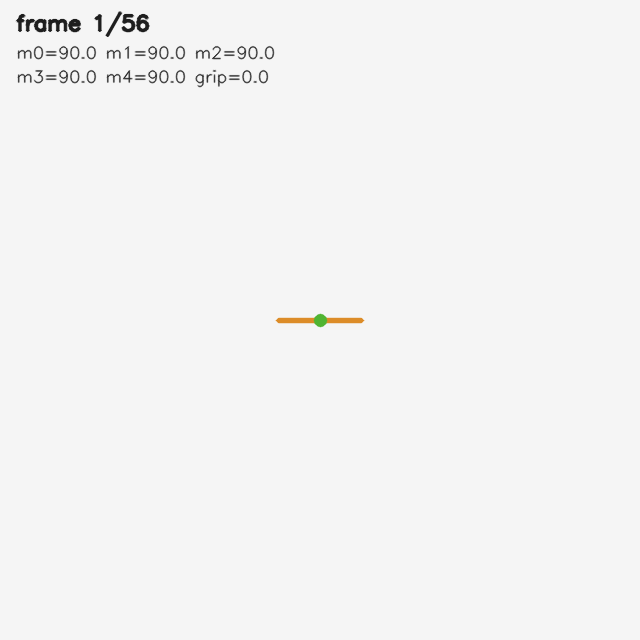

In [4]:
from IPython.display import Image as IPyImage, display
from pathlib import Path
import numpy as np
from robot_arm_servo_model import HOME_DEG, build_visuals, gripper_open_mm, solve_servo_from_target

BASE_MM = np.asarray(ROBOT_BASE_MM if "ROBOT_BASE_MM" in globals() else [0.0, 0.0, 500.0], dtype=np.float64)
TARGET_MM = np.asarray(grasp_point_mm if "grasp_point_mm" in globals() else BASE_MM + np.array([180.0, 0.0, 60.0]), dtype=np.float64)
TARGET_DEG = solve_servo_from_target(TARGET_MM, BASE_MM)
print("Servo trajectory results")
print("  semantics: accumulated relative angles, 90 deg => +Z aligned links")
print("  home deg     =", np.round(HOME_DEG, 2))
print("  target deg   =", np.round(TARGET_DEG, 2))
print("Motor 0: base left=180, right=0")
print("Motors 1,2,3: accumulated relative angles, 90 keeps each link vertical")
print("Motor 4: left=180, right=0")
print("Motor 5: gripper closed=180, open=0")
print("Target gripper opening (mm) =", round(gripper_open_mm(TARGET_DEG[5]), 2))
FIG_SIM_3D, GIF_PATH = build_visuals(TARGET_DEG, BASE_MM, Path.cwd() / "captures_3d" / "robot_arm_locate_shared_servo.gif", scene_objects=scene_objects if "scene_objects" in globals() else None, title="Servo 3D Interactive View: Shared Model Trajectory")
print("Saved shared servo GIF:", GIF_PATH)
display(IPyImage(filename=str(GIF_PATH)))
FIG_SIM_3D.add_scatter3d(x=[TARGET_MM[0]], y=[TARGET_MM[2]], z=[TARGET_MM[1]], mode="markers+text", name="grasp target", text=["grasp target"], textposition="bottom center", marker={"size": 6, "color": "rgb(220,60,60)"})
FIG_SIM_3D.show()
